<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/GAMES_SETTINGS_OPTIMIZER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import random
import pandas as pd

# CPU list
cpus = [
    # Intel Core Ultra Series 2 (2024-2025) - "Arrow Lake" (Desktop) & "Lunar Lake" (Mobile)
    ("Core Ultra 9 285K", 42000), ("Core Ultra 9 285", 41000), ("Core Ultra 9 275", 40000), ("Core Ultra 9 275V", 39000),
    ("Core Ultra 7 265K", 38000), ("Core Ultra 7 265KF", 37500), ("Core Ultra 7 265", 37000), ("Core Ultra 7 255", 36000), ("Core Ultra 7 268V", 35500), ("Core Ultra 7 266V", 35000), ("Core Ultra 7 266VH", 34500), ("Core Ultra 7 258V", 34000),
    ("Core Ultra 5 245K", 33000), ("Core Ultra 5 245KF", 32500), ("Core Ultra 5 245", 32000), ("Core Ultra 5 235", 31000), ("Core Ultra 5 225", 30500), ("Core Ultra 5 225F", 30000), ("Core Ultra 5 228V", 29500), ("Core Ultra 5 226V", 29000),
    # Intel Core Ultra Series 1 (2023-2024) - "Meteor Lake" (Mobile)
    ("Core Ultra 9 185H", 33000),
    ("Core Ultra 7 165H", 30000), ("Core Ultra 7 165U", 29000), ("Core Ultra 7 155H", 28000), ("Core Ultra 7 155U", 27000),
    ("Core Ultra 5 135H", 26000), ("Core Ultra 5 135U", 25000), ("Core Ultra 5 125H", 24000), ("Core Ultra 5 125U", 23000),
    # 14th Gen Intel Core (2024) - "Raptor Lake Refresh"
    ("Core i9-14900KS", 41000), ("Core i9-14900K", 38000), ("Core i9-14900KF", 37500), ("Core i9-14900", 36000), ("Core i9-14900F", 35000), ("Core i9-14900HX", 34000),
    ("Core i7-14700K", 27000), ("Core i7-14700KF", 26500), ("Core i7-14700", 25000), ("Core i7-14700F", 24500), ("Core i7-14700HX", 23000),
    ("Core i5-14600K", 19000), ("Core i5-14600KF", 18500), ("Core i5-14500", 17000), ("Core i5-14400F", 16500), ("Core i5-14400", 16000), ("Core i5-14400HX", 15000),
    ("Core i3-14100", 12000), ("Core i3-14100F", 11500),
    # 13th Gen Intel Core (2022-2023) - "Raptor Lake"
    ("Core i9-13900KS", 39000), ("Core i9-13900K", 35000), ("Core i9-13900KF", 34500), ("Core i9-13900", 33000), ("Core i9-13900F", 32500), ("Core i9-13900HX", 31000),
    ("Core i7-13700K", 25000), ("Core i7-13700KF", 24500), ("Core i7-13700", 23000), ("Core i7-13700F", 22500), ("Core i7-13700HX", 21000),
    ("Core i5-13600K", 18000), ("Core i5-13600KF", 17500), ("Core i5-13500", 16000), ("Core i5-13400F", 15500), ("Core i5-13400", 15000), ("Core i5-13500HX", 14000),
    ("Core i3-13100", 11000), ("Core i3-13100F", 10500),
    # 12th Gen Intel Core (2021-2022) - "Alder Lake"
    ("Core i9-12900K", 30000), ("Core i9-12900KF", 29500), ("Core i9-12900", 28000), ("Core i9-12900F", 27500),
    ("Core i7-12700K", 22000), ("Core i7-12700KF", 21500), ("Core i7-12700", 20000), ("Core i7-12700F", 19500),
    ("Core i5-12600K", 16000), ("Core i5-12600KF", 15500), ("Core i5-12500", 14500), ("Core i5-12400F", 13500), ("Core i5-12400", 13000),
    ("Core i3-12300", 10000), ("Core i3-12100F", 9500), ("Core i3-12100", 9000),
    # 11th Gen Intel Core (2021) - "Rocket Lake" / "Tiger Lake" (Mobile)
    ("Core i9-11900K", 22000), ("Core i9-11900KF", 21500), ("Core i9-11900", 20000), ("Core i9-11900F", 19500),
    ("Core i7-11700K", 18000), ("Core i7-11700KF", 17500), ("Core i7-11700", 16000), ("Core i7-11700F", 15500),
    ("Core i5-11600K", 14000), ("Core i5-11600KF", 13500), ("Core i5-11500", 12500), ("Core i5-11400F", 12000), ("Core i5-11400", 11500),
    ("Core i3-11300", 9000), ("Core i3-11100", 8500),
    # 10th Gen Intel Core (2020) - "Comet Lake" / "Ice Lake" (Mobile)
    ("Core i9-10900K", 20000), ("Core i9-10900KF", 19500), ("Core i9-10900", 18000), ("Core i9-10900F", 17500),
    ("Core i7-10700K", 16000), ("Core i7-10700KF", 15500), ("Core i7-10700", 14000), ("Core i7-10700F", 13500),
    ("Core i5-10600K", 12500), ("Core i5-10600KF", 12000), ("Core i5-10500", 11000), ("Core i5-10400F", 10500), ("Core i5-10400", 12500),
    ("Core i3-10320", 9800), ("Core i3-10300", 9500), ("Core i3-10100F", 9200), ("Core i3-10100", 9500),

    # AMD 3rd Generation Ryzen (Zen 2 Architecture)
    ("Ryzen 9 3950X", 20000), ("Ryzen 9 3900XT", 19500), ("Ryzen 9 3900X", 19000),
    ("Ryzen 7 3800XT", 16000), ("Ryzen 7 3800X", 15500), ("Ryzen 7 3700X", 14000),
    ("Ryzen 5 3600XT", 12000), ("Ryzen 5 3600", 9000), ("Ryzen 5 3500X", 8500),
    ("Ryzen 3 3300X", 8000), ("Ryzen 3 3100", 7000),
    ("Ryzen 5 3400G", 8000), ("Ryzen 3 3200G", 7500),
    ("Ryzen 9 4900H", 18000), ("Ryzen 7 4800H", 15000), ("Ryzen 7 4700U", 14000),
    ("Ryzen 5 4600H", 12000), ("Ryzen 5 4500U", 11000), ("Ryzen 3 4300U", 9000),
    # AMD 4th Generation Ryzen (Zen 3 Architecture) - 5000 Series Desktop
    ("Ryzen 9 5950X", 30000), ("Ryzen 9 5900X", 32000),
    ("Ryzen 7 5800X3D", 26000), ("Ryzen 7 5800X", 25000),
    ("Ryzen 5 5600X", 21000), ("Ryzen 5 5600", 20000), ("Ryzen 5 5500", 19000),
    ("Ryzen 7 5700G", 18000), ("Ryzen 5 5600G", 16000),
    ("Ryzen 9 5980HX", 28000), ("Ryzen 7 5800H", 24000), ("Ryzen 7 5700U", 22000),
    ("Ryzen 5 5600H", 20000), ("Ryzen 5 5500U", 19000),
    # AMD 5th Generation Ryzen (Zen 4 Architecture) - 7000 Series Desktop
    ("Ryzen 9 7950X3D", 40000), ("Ryzen 9 7950X", 39000), ("Ryzen 9 7900X", 38000),
    ("Ryzen 7 7800X3D", 30000), ("Ryzen 7 7700X", 29000),
    ("Ryzen 5 7600X", 23000),
    ("Ryzen 9 7945HX", 35000), ("Ryzen 7 7845HX", 32000), ("Ryzen 5 7645HX", 27000),
    # AMD 6th Generation Ryzen (Rembrandt - Mobile Focused)
    ("Ryzen 9 6980HX", 26000), ("Ryzen 7 6800H", 22000), ("Ryzen 5 6600H", 19000)
]

# GPU list
gpus = [
    # Radeon RX 9000 Series (Upcoming/RDNA 4)
    ("RX 9070 XT", 50000), ("RX 9070", 48000), ("RX 9060 XT", 45000),
    # Radeon RX 7000 Series (RDNA 3)
    ("RX 7900 XTX", 48000), ("RX 7900 XT", 45000), ("RX 7900 GRE", 42000), ("RX 7800 XT", 30000), ("RX 7700 XT", 28000), ("RX 7600 XT", 26000), ("RX 7600", 24000),
    ("RX 7900M", 40000), ("RX 7800M", 35000), ("RX 7600M XT", 30000), ("RX 7600M", 28000), ("RX 7700S", 29000), ("RX 7600S", 27000),
    # Radeon RX 6000 Series (RDNA 2)
    ("RX 6950 XT", 38000), ("RX 6900 XT", 36000), ("RX 6800 XT", 32000), ("RX 6800", 30000), ("RX 6750 XT", 29000), ("RX 6700 XT", 27000), ("RX 6700", 25000), ("RX 6650 XT", 24000), ("RX 6600 XT", 22000), ("RX 6600", 17000), ("RX 6500 XT", 12000), ("RX 6400", 9000),
    ("RX 6850M XT", 34000), ("RX 6800M", 30000), ("RX 6700M", 26000), ("RX 6600M", 21000), ("RX 6800S", 28000), ("RX 6700S", 25000), ("RX 6600S", 20000),
    # Radeon RX 5000 Series (RDNA 1)
    ("RX 5700 XT", 20000), ("RX 5700", 18000), ("RX 5600 XT", 16000), ("RX 5600", 15000), ("RX 5500 XT", 12000), ("RX 5300", 9000),
    ("RX 5700M", 17000), ("RX 5600M", 14000), ("RX 5500M", 11000), ("RX 5300M", 8000),
    # Radeon RX 500/400 Series (Polaris)
    ("RX 590", 10000), ("RX 580", 9500), ("RX 570", 9000), ("RX 560", 6000), ("RX 550", 5000), ("RX 480", 8500), ("RX 470", 8000), ("RX 460", 5500),
    # Radeon RX Vega Series
    ("RX Vega 64", 15000), ("RX Vega 56", 13000),

    # GeForce RTX 50 Series (Upcoming 2025–2026)
    ("RTX 5090", 60000), ("RTX 5080", 55000), ("RTX 5070 Ti", 50000), ("RTX 5070", 48000), ("RTX 5060 Ti", 42000), ("RTX 5060", 40000), ("RTX 5050", 35000),
    # GeForce RTX 40 Series (Ada Lovelace)
    ("RTX 4090", 45000), ("RTX 4080 SUPER", 42000), ("RTX 4080", 40000), ("RTX 4070 Ti SUPER", 38000), ("RTX 4070 Ti", 36000), ("RTX 4070 SUPER", 34000), ("RTX 4070", 32000),
    ("RTX 4060 Ti", 28000), ("RTX 4060", 26000), ("RTX 4050", 22000),
    # GeForce RTX 30 Series (Ampere)
    ("RTX 3090 Ti", 40000), ("RTX 3090", 38000),
    ("RTX 3080 Ti", 35000), ("RTX 3080", 30000), ("RTX 3070 Ti", 25000), ("RTX 3070", 22000),
    ("RTX 3060 Ti", 20000), ("RTX 3060", 18000), ("RTX 3050", 14000),
    # GeForce RTX 20 Series (Turing)
    ("RTX 2080 Ti", 28000), ("RTX 2080 SUPER", 25000), ("RTX 2080", 23000),
    ("RTX 2070 SUPER", 21000), ("RTX 2070", 19000), ("RTX 2060 SUPER", 17000), ("RTX 2060", 16000),
    # GeForce GTX 10 / 16 Series (Pascal/Turing)
    ("GTX 1080 Ti", 18000), ("GTX 1080", 16000),
    ("GTX 1070 Ti", 14000), ("GTX 1070", 13000), ("GTX 1060", 12000),
    ("GTX 1660 Ti", 11000), ("GTX 1660 SUPER", 10500), ("GTX 1660", 10000),
    ("GTX 1050 Ti", 9000), ("GTX 1050", 8000), ("GT 1030", 4000), ("GTX 1650", 9500)
]

games = [
    "Resident Evil 2 Remake","Resident Evil 3 Remake","Resident Evil 4 Remake","Resident Evil 7","Resident Evil 8","Resident Evil 9",
    "God of War","Ghost of Tsushima","Days Gone Remake",
    "Devil May Cry 5","Uncharted 4","Red Dead Redemption 2",
    "Last of Us Part I Remake","Last of Us Part II Remake",
    "Cyberpunk 2077","Mortal Kombat 1","Tekken 7","Tekken 8",
    "Elden Ring","Elden Ring: Shadow of the Erdtree",
    "Grand Theft Auto V","Silent Hill f",
    "Assassin's Creed IV: Black Flag","Metal Gear Solid V",
    "Dark Souls Remastered","Dark Souls 2","Dark Souls 3",
    "Watch Dogs 2","Tomb Raider (2013)","Rise of the Tomb Raider","Shadow of the Tomb Raider",
    "The Evil Within","The Evil Within 2",
    "Far Cry 3","Far Cry 4","Far Cry 5",
    "Sekiro",
    "The Witcher 3: Wild Hunt", "Horizon Zero Dawn", "Horizon Forbidden West", "Marvel's Spider-Man Remastered", "Marvel's Spider-Man: Miles Morales",
    "Batman: Arkham Knight", "Mad Max", "Control", "Dishonored 2", "Prey (2017)", "Deus Ex: Mankind Divided",
    "Hitman 3", "Death Stranding", "Resident Evil Village", "God of War Ragnarök", "Assassin's Creed Valhalla", "Assassin's Creed Odyssey", "Assassin's Creed Origins",
    "Star Wars Jedi: Fallen Order", "Star Wars Jedi: Survivor", "Marvel's Guardians of the Galaxy", "Mass Effect Legendary Edition",
    "DOOM Eternal", "Wolfenstein II: The New Colossus", "Metro Exodus", "Dying Light 2 Stay Human", "Borderlands 3", "Tiny Tina's Wonderlands",
    "Diablo IV", "Hogwarts Legacy", "Forza Horizon 5", "Microsoft Flight Simulator", "Assetto Corsa Competizione",
    "Baldur's Gate 3", "Starfield", "Hades", "Persona 5 Royal", "Final Fantasy VII Remake", "Final Fantasy XV",
    "Gears 5", "Halo Infinite", "Apex Legends", "Call of Duty: Warzone", "Fortnite", "Valorant", "Overwatch 2",
    "League of Legends", "Dota 2", "CS: GO", "CS2", "Rainbow Six Siege", "Rocket League",
    "No Man's Sky", "Minecraft", "Terraria", "Stardew Valley", "Grand Theft Auto Online", "Red Dead Online",
    "Sea of Thieves", "Fallout 4", "Skyrim", "Doom (2016)", "Dishonored", "Portal 2", "Half-Life 2",
    "BioShock Infinite", "Borderlands 2", "The Outer Worlds", "Cyberpunk 2077: Phantom Liberty",
    "Remnant II", "Armored Core VI: Fires of Rubicon", "Star Wars Outlaws", "Avowed", "Fable (Upcoming)",
    "The Elder Scrolls VI (Upcoming)", "Grand Theft Auto VI (Upcoming)", "Assassin's Creed Hexe (Upcoming)",
    "Control 2 (Upcoming)", "Death Stranding 2 (Upcoming)", "Silent Hill 2 Remake", "Metal Gear Solid 3 Remake",
    "Dragon's Dogma 2", "Helldivers 2", "Palworld", "Phantom Blade Zero", "Black Myth: Wukong",
    "Stalker 2: Heart of Chornobyl", "Warhammer 40,000: Space Marine 2", "The Witcher 4 (Upcoming)",
    "Project L (Upcoming)", "Overwatch", "Destiny 2", "Warframe", "Genshin Impact", "Honkai Star Rail",
    "Roblox", "PUBG: Battlegrounds", "Rust", "Escape From Tarkov", "DayZ", "Among Us",
    "Phasmophobia", "Valheim", "Factorio", "Subnautica", "ARK: Survival Evolved", "Conan Exiles",
    "New World", "Lost Ark", "EVE Online", "World of Warcraft", "Final Fantasy XIV", "Guild Wars 2",
    "Elder Scrolls Online", "Runescape", "OSRS", "Albion Online", "Black Desert Online",
    "Monster Hunter: World", "Monster Hunter Rise", "Street Fighter 6", "Guilty Gear Strive", "SFV",
    "Mortal Kombat 11", "Injustice 2", "Killer Instinct", "Smash Bros Ultimate",
    "Mario Kart 8 Deluxe", "Zelda: Breath of the Wild", "Zelda: Tears of the Kingdom", "Pokémon Scarlet/Violet",
    "Super Mario Odyssey", "Animal Crossing: New Horizons", "Splatoon 3", "Metroid Prime Remastered",
    "Pikmin 4", "Kirby and the Forgotten Land", "Bayonetta 3", "Xenoblade Chronicles 3",
    "Dead Space Remake", "Alan Wake 2", "Divinity: Original Sin 2",
    "Pathfinder: Wrath of the Righteous", "Disco Elysium", "Planescape: Torment", "Fallout: New Vegas",
    "Pillars of Eternity", "Tyranny", "Wasteland 3", "The Witcher 2",
    "Assassin's Creed Unity", "Assassin's Creed Syndicate",
    "Far Cry 6", "Far Cry New Dawn", "Doom 3", "Doom 64", "Quake",
    "Prey (2006)", "System Shock 2", "System Shock Remake", "BioShock", "BioShock 2",
    "Dishonored: Death of the Outsider", "Wolfenstein: The New Order", "Wolfenstein: The Old Blood",
    "Borderlands", "Borderlands: The Pre-Sequel", "Mass Effect", "Mass Effect 2", "Mass Effect 3",
    "Dragon Age: Origins", "Dragon Age II", "Dragon Age: Inquisition", "Star Wars: KOTOR", "Star Wars: KOTOR 2",
    "Half-Life: Alyx", "Bonelab", "Beat Saber", "Resident Evil 7 VR", "Half-Life", "Half-Life: Blue Shift",
    "Half-Life: Opposing Force", "Team Fortress 2", "Left 4 Dead 2", "Garry's Mod",
    "Sons of the Forest", "Project Zomboid", "Minecraft Dungeons", "Minecraft Legends",
    "Terraria: Journey's End", "Satisfactory", "Cities: Skylines", "Cities: Skylines II",
    "Civilization VI", "Europa Universalis IV", "Crusader Kings III", "Stellaris", "Victoria 3",
    "Total War: Warhammer III", "Age of Empires IV", "StarCraft II", "WarCraft III Reforged",
    "Heroes of the Storm",
    "Gran Turismo 7", "F1 23", "F1 24 (Upcoming)", "WRC Generations", "Dirt Rally 2.0",
    "The Crew Motorfest", "Need for Speed Unbound", "Forza Motorsport", "Iracing", "Assetto Corsa",
    "Project CARS 3", "GRID Legends", "NBA 2K24", "FIFA 23", "EA Sports FC 24", "Madden NFL 24",
    "NHL 24", "UFC 5", "WWE 2K23", "PGA Tour 2K23", "eFootball 2024",
    "Spider-Man 2", "Alan Wake Remastered", "Hades II (Upcoming)", "Hollow Knight Silksong (Upcoming)",
    "Metroid Prime 4 (Upcoming)", "State of Decay 3 (Upcoming)",
    "Perfect Dark (Upcoming)", "Everwild (Upcoming)", "The Outer Worlds 2 (Upcoming)",
    "The Division 3 (Upcoming)", "Ghost Recon Breakpoint", "Ghost Recon Wildlands",
    "Watch Dogs Legion", "Immortals Fenyx Rising", "Skull and Bones (Upcoming)",
    "Prince of Persia: The Lost Crown", "Avatar: Frontiers of Pandora",
    "Star Wars Eclipse (Upcoming)", "Indiana Jones and the Great Circle (Upcoming)",
    "Fable 2", "Fable 3", "Gears of War", "Gears of War 2", "Gears of War 3",
    "Halo: Combat Evolved", "Halo 2", "Halo 3", "Halo: Reach", "Halo 4", "Halo 5",
    "Forza Horizon", "Forza Horizon 2", "Forza Horizon 3", "Forza Horizon 4",
    "Sea of Stars", "Octopath Traveler II", "Final Fantasy XVI", "Persona 3 Reload",
    "Like a Dragon: Infinite Wealth", "Granblue Fantasy Relink", "Unicorn Overlord",
    "Eiyuden Chronicle: Hundred Heroes", "Paper Mario: The Thousand-Year Door Remake",
    "Dragon Quest Monsters: The Dark Prince", "Super Mario RPG Remake",
    "The Legend of Heroes: Trails into Reverie", "Ys X: Nordics"
]

# Remove duplicates and sort for consistency
games = sorted(list(set(games)))

resolutions = ["1920x1080","2560x1440","3840x2160"]
settings = ["Low","Medium","High","Ultra"] # Overall graphics settings
dlss = ["Off","Quality","Balanced","Performance"]
rt = ["Off","Low","Medium","High"]

# New detailed settings lists
cpu_types = ["Laptop", "Desktop"]
shadow_qualities = ["Low", "Medium", "High", "Ultra"]
aa_modes = ["Off", "FXAA", "TAA", "MSAA 2x", "MSAA 4x", "MSAA 8x"]
nvidia_power_modes = ["Prefer maximum performance", "Optimal power", "Adaptive"]
nvidia_low_latency_modes = ["Off", "On", "Ultra"]
nvidia_texture_filtering_qualities = ["High performance", "Performance", "Quality", "High Quality"]
os_game_modes = ["On", "Off"]
os_hags_modes = ["On", "Off"]
os_power_plans = ["High Performance", "Balanced", "Power Saver"]

# Additional NVIDIA and in-game settings
preferred_graphics_processors = ["High-performance NVIDIA processor", "Integrated graphics"]
max_frame_rates = ["Off", "60", "75", "120", "144", "240"]
v_sync_modes = ["Off", "On", "Fast", "Adaptive"]
triple_buffering_options = ["Off", "On"]
shader_cache_sizes = ["Unlimited", "10GB", "100GB"]
anisotropic_sample_optimization_options = ["On", "Off"]
threaded_optimization_options = ["Auto", "On", "Off"]
image_scaling_options = ["Off", "On"]
in_game_overlay_options = ["Enabled", "Disabled"]
whisper_mode_options = ["Off", "On"]
battery_boost_options = ["Off", "On"]

# New list for Refresh Rates
refresh_rates = [60, 75, 120, 144, 165, 240, 360]

rows = []

for _ in range(2000):
    cpu = random.choice(cpus)
    gpu = random.choice(gpus)
    game = random.choice(games)

    # Randomly select new detailed settings
    cpu_type = random.choice(cpu_types)
    shadow_quality = random.choice(shadow_qualities)
    aa_mode = random.choice(aa_modes)
    nvidia_power_mode = random.choice(nvidia_power_modes)
    nvidia_low_latency_mode = random.choice(nvidia_low_latency_modes)
    nvidia_texture_filtering_quality = random.choice(nvidia_texture_filtering_qualities)
    os_game_mode = random.choice(os_game_modes)
    os_hags_mode = random.choice(os_hags_modes)
    os_power_plan = random.choice(os_power_plans)

    # Randomly select values for the new additional settings
    preferred_graphics_processor = random.choice(preferred_graphics_processors)
    max_frame_rate = random.choice(max_frame_rates)
    v_sync = random.choice(v_sync_modes)
    triple_buffering = random.choice(triple_buffering_options)
    shader_cache_size = random.choice(shader_cache_sizes)
    anisotropic_sample_optimization = random.choice(anisotropic_sample_optimization_options)
    threaded_optimization = random.choice(threaded_optimization_options)
    image_scaling = random.choice(image_scaling_options)
    in_game_overlay = random.choice(in_game_overlay_options)
    whisper_mode = random.choice(whisper_mode_options)
    battery_boost = random.choice(battery_boost_options)

    # Randomly select a refresh rate
    refresh_rate = random.choice(refresh_rates)

    base_fps = (gpu[1] / 300) + (cpu[1] / 500)

    setting_factor = random.choice([0.6,0.8,1.0,1.2])
    res_factor = random.choice([1.2,1.0,0.7])

    fps = int(base_fps * setting_factor * res_factor + random.randint(-5,5))

    row = [
        cpu[0], cpu[1], cpu_type,
        gpu[0], gpu[1], random.choice(["Laptop","Desktop"]), # GPU_Type already present
        random.choice([8,16,32]),
        game,
        random.choice(resolutions),
        refresh_rate, # Add refresh rate
        random.choice(settings), # Overall Graphics_Settings
        shadow_quality,
        aa_mode,
        random.choice(dlss),
        random.choice(rt),
        nvidia_power_mode,
        nvidia_low_latency_mode,
        nvidia_texture_filtering_quality,
        os_game_mode,
        os_hags_mode,
        os_power_plan,
        preferred_graphics_processor,
        max_frame_rate,
        v_sync,
        triple_buffering,
        shader_cache_size,
        anisotropic_sample_optimization,
        threaded_optimization,
        image_scaling,
        in_game_overlay,
        whisper_mode,
        battery_boost,
        max(fps,20)
    ]

    rows.append(row)

df = pd.DataFrame(rows, columns=[
    "CPU_Name","CPU_Score","CPU_Type","GPU_Name","GPU_Score","GPU_Type",
    "RAM_Size","Game_Name","Resolution","Refresh_Rate","Graphics_Settings",
    "Shadow_Quality","Anti_Aliasing_Mode","DLSS_FSR","Ray_Tracing",
    "NVIDIA_Power_Management_Mode","NVIDIA_Low_Latency_Mode","NVIDIA_Texture_Filtering_Quality",
    "OS_Game_Mode","OS_Hardware_Accelerated_GPU_Scheduling","OS_Power_Plan",
    "Preferred_Graphics_Processor", "Max_Frame_Rate", "V_Sync", "Triple_Buffering",
    "Shader_Cache_Size", "Anisotropic_Sample_Optimization", "Threaded_Optimization",
    "Image_Scaling_NIS", "In_Game_Overlay", "Whisper_Mode", "Battery_Boost",
    "FPS"
])

df.to_csv("game_performance_dataset.csv", index=False)

print("Dataset Generated Successfully!")

Dataset Generated Successfully!


In [ ]:
from google.colab import files
files.download('game_performance_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv("game_performance_dataset_FINAL.csv")
df

,CPU_Name,CPU_Score,CPU_Type,GPU_Name,GPU_Score,GPU_Type,RAM_Size,Game_Name,Resolution,Refresh_Rate,...,V_Sync,Triple_Buffering,Shader_Cache_Size,Anisotropic_Sample_Optimization,Threaded_Optimization,Image_Scaling_NIS,In_Game_Overlay,Whisper_Mode,Battery_Boost,FPS
0,Core i7-14700HX,23000,Laptop,RX 6850M XT,34000,Desktop,32,Fable (Upcoming),3840x2160,165,...,Off,On,100GB,On,Off,On,Enabled,Off,On,94
1,Core Ultra 5 225,30500,Laptop,RTX 5060 Ti,42000,Desktop,32,Honkai Star Rail,1920x1080,360,...,Fast,Off,Unlimited,Off,Auto,On,Disabled,Off,On,236
2,Ryzen 9 3900X,19000,Laptop,GTX 1660,10000,Desktop,32,Terraria,1920x1080,120,...,Off,On,10GB,On,Auto,On,Enabled,On,On,66
3,Core Ultra 5 235,31000,Laptop,RX 9060 XT,45000,Desktop,16,Gran Turismo 7,1920x1080,165,...,On,Off,10GB,On,Off,Off,Enabled,Off,On,199
4,Ryzen 5 5600X,21000,Laptop,RX 7600S,27000,Laptop,16,NHL 24,1920x1080,165,...,Adaptive,Off,Unlimited,Off,Auto,On,Enabled,Off,On,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Ryzen 7 4700U,14000,Laptop,RX 6400,9000,Desktop,16,Hades,3840x2160,75,...,On,Off,100GB,Off,Auto,Off,Disabled,Off,On,73
1996,Core i3-12300,10000,Laptop,RX 7800 XT,30000,Desktop,32,Gears 5,3840x2160,360,...,Fast,Off,100GB,Off,On,On,Enabled,On,Off,119
1997,Core Ultra 5 135H,26000,Desktop,RTX 3070 Ti,25000,Laptop,8,Fable (Upcoming),3840x2160,75,...,Fast,Off,100GB,On,Off,Off,Enabled,Off,Off,167
1998,Ryzen 7 4800H,15000,Desktop,RX 5700 XT,20000,Desktop,32,Smash Bros Ultimate,1920x1080,165,...,Fast,Off,Unlimited,Off,On,On,Disabled,On,Off,118


In [ ]:
df['Game_Name']

,Game_Name
0,Fable (Upcoming)
1,Honkai Star Rail
2,Terraria
3,Gran Turismo 7
4,NHL 24
...,...
1995,Hades
1996,Gears 5
1997,Fable (Upcoming)
1998,Smash Bros Ultimate


EDA

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   CPU_Name                                2000 non-null   object
 1   CPU_Score                               2000 non-null   int64 
 2   CPU_Type                                2000 non-null   object
 3   GPU_Name                                2000 non-null   object
 4   GPU_Score                               2000 non-null   int64 
 5   GPU_Type                                2000 non-null   object
 6   RAM_Size                                2000 non-null   int64 
 7   Game_Name                               2000 non-null   object
 8   Resolution                              2000 non-null   object
 9   Refresh_Rate                            2000 non-null   int64 
 10  Graphics_Settings                       2000 non-null   object
 11  Shad

In [ ]:
print('\nMissing values in each column:')
print(df.isnull().sum())


Missing values in each column:
CPU_Name                                  0
CPU_Score                                 0
CPU_Type                                  0
GPU_Name                                  0
GPU_Score                                 0
GPU_Type                                  0
RAM_Size                                  0
Game_Name                                 0
Resolution                                0
Refresh_Rate                              0
Graphics_Settings                         0
Shadow_Quality                            0
Anti_Aliasing_Mode                        0
DLSS_FSR                                  0
Ray_Tracing                               0
NVIDIA_Power_Management_Mode              0
NVIDIA_Low_Latency_Mode                   0
NVIDIA_Texture_Filtering_Quality          0
OS_Game_Mode                              0
OS_Hardware_Accelerated_GPU_Scheduling    0
OS_Power_Plan                             0
Preferred_Graphics_Processor              0


In [ ]:
display(df.describe())

,CPU_Score,GPU_Score,RAM_Size,Refresh_Rate,FPS
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,22098.550000,24285.000000,18.732000,165.148500,108.356000
std,9379.707477,12831.127929,9.997307,97.040805,56.079735
min,7000.000000,4000.000000,8.000000,60.000000,20.000000
25%,14500.000000,13000.000000,8.000000,75.000000,68.000000
50%,20000.000000,24000.000000,16.000000,144.000000,98.000000
75%,30000.000000,34000.000000,32.000000,240.000000,137.000000
max,42000.000000,60000.000000,32.000000,360.000000,377.000000


<Axes: >

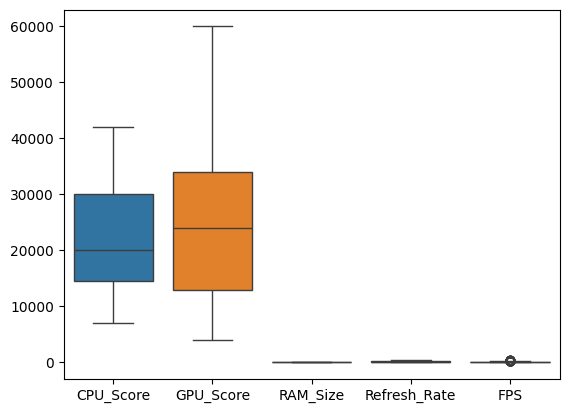

In [ ]:
sns.boxplot(df)

### Distribution of FPS

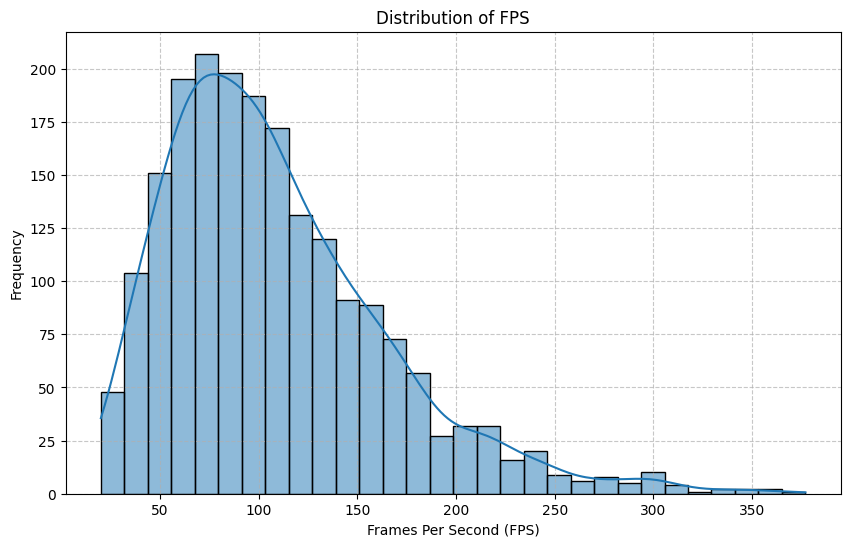

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['FPS'], bins=30, kde=True)
plt.title('Distribution of FPS')
plt.xlabel('Frames Per Second (FPS)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. CPU Score

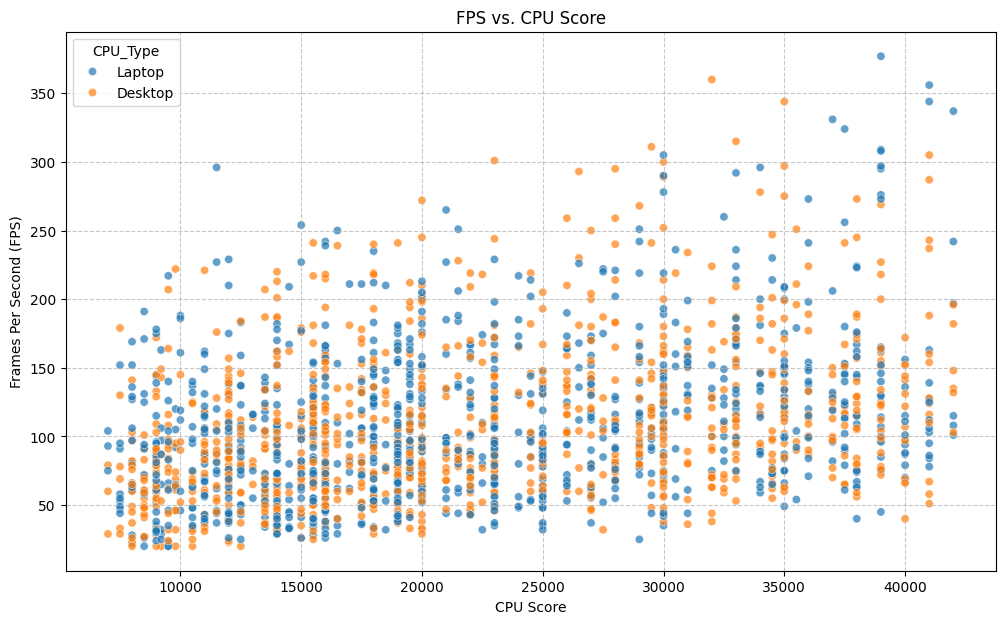

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CPU_Score', y='FPS', data=df, hue='CPU_Type', alpha=0.7)
plt.title('FPS vs. CPU Score')
plt.xlabel('CPU Score')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. GPU Score

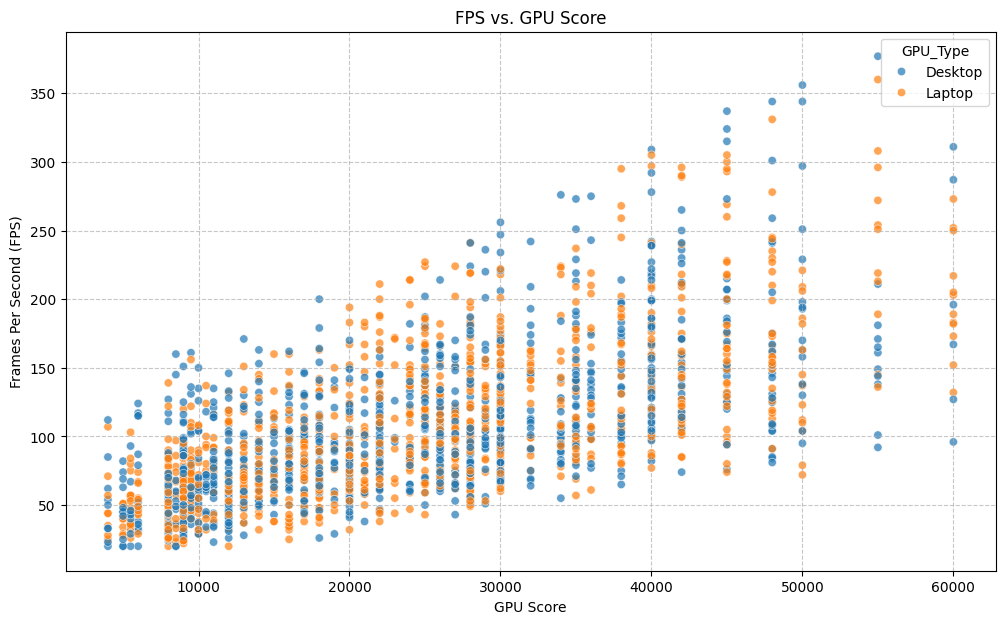

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='GPU_Score', y='FPS', data=df, hue='GPU_Type', alpha=0.7)
plt.title('FPS vs. GPU Score')
plt.xlabel('GPU Score')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. CPU Score vs. GPU Score (3D Scatter Plot)

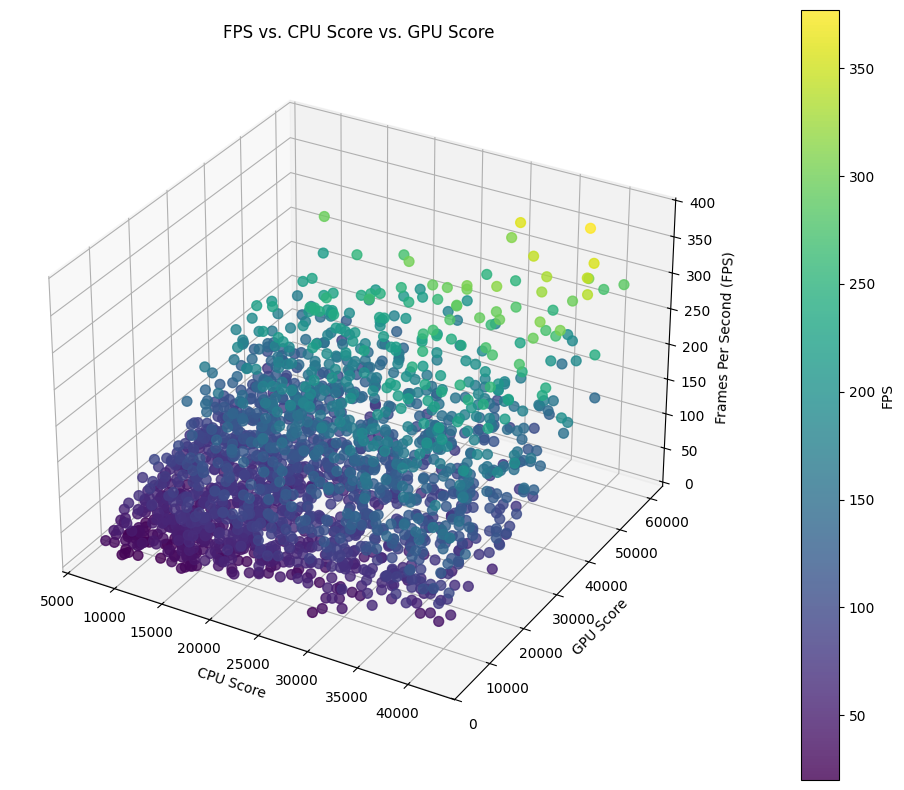

In [151]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
sc = ax.scatter(df['CPU_Score'], df['GPU_Score'], df['FPS'], c=df['FPS'], cmap='viridis', s=50, alpha=0.8)

# Set labels and title
ax.set_xlabel('CPU Score')
ax.set_ylabel('GPU Score')
ax.set_zlabel('Frames Per Second (FPS)')
ax.set_title('FPS vs. CPU Score vs. GPU Score')

# Add a color bar
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('FPS')

plt.show()

### FPS vs. Resolution

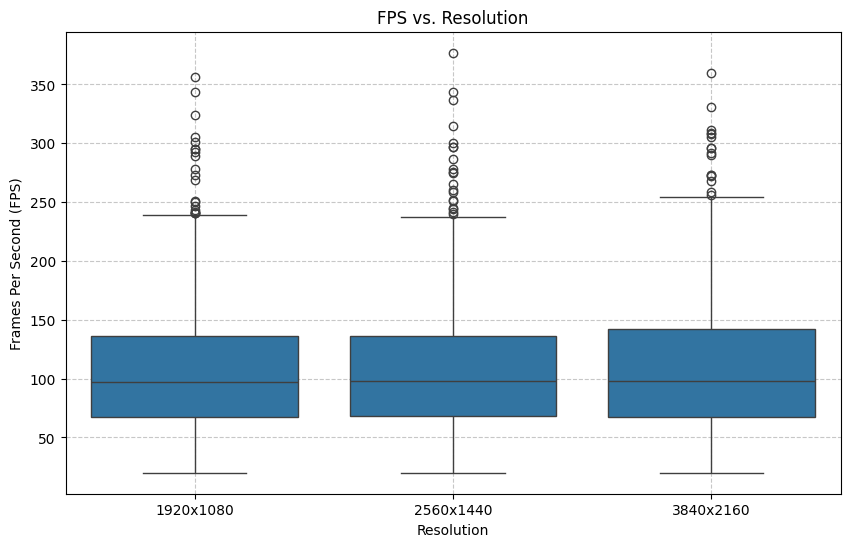

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Resolution', y='FPS', data=df, order=['1920x1080', '2560x1440', '3840x2160'])
plt.title('FPS vs. Resolution')
plt.xlabel('Resolution')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. Graphics Settings

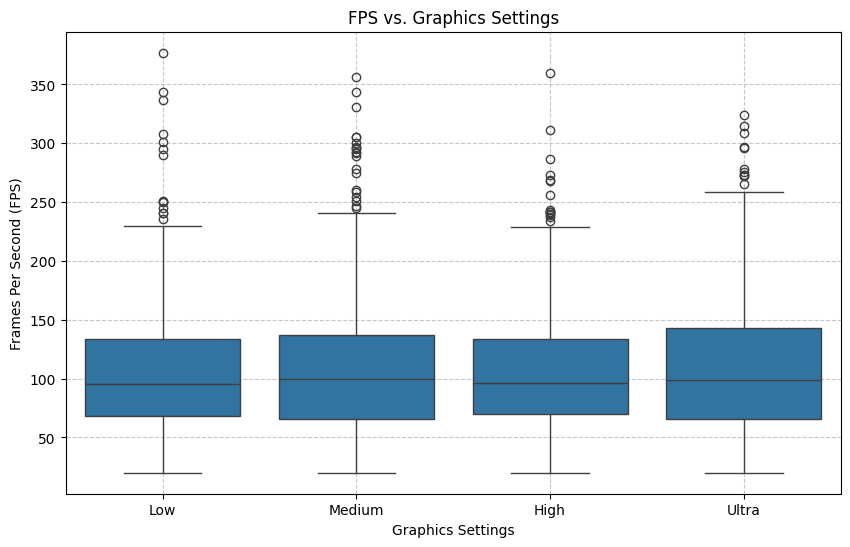

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Graphics_Settings', y='FPS', data=df, order=['Low', 'Medium', 'High', 'Ultra'])
plt.title('FPS vs. Graphics Settings')
plt.xlabel('Graphics Settings')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

DIVIDE FEATURES

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# features X mai FPS choddke sabb kuch and y mai fps
X = df.drop('FPS', axis=1)
y = df['FPS']


numerical_cols = ['CPU_Score', 'GPU_Score', 'RAM_Size', 'Refresh_Rate']
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Get all unique categories for each categorical column from the entire X DataFrame
# This ensures the OneHotEncoder learns all possible categories from the start.
all_categories = [X[col].unique().tolist() for col in categorical_cols]

# ColumnTransformer
# We will scale numerical features and one-hot encode categorical features.
# CPU_Score and GPU_Score are treated as numerical features that need scaling.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        # Pass the pre-defined categories to OneHotEncoder
        ('cat', OneHotEncoder(handle_unknown='ignore', categories=all_categories), categorical_cols)
    ])

# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print("Data preparation complete. X, y, X_train, X_test, y_train, y_test, and preprocessor are defined.")

X_train shape: (1600, 32), y_train shape: (1600,)
X_test shape: (400, 32), y_test shape: (400,)
Data preparation complete. X, y, X_train, X_test, y_train, y_test, and preprocessor are defined.


### Initial Model Training and Evaluation



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear_Regression': LinearRegression(),
    'Random_Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient_Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

comparison_df = pd.DataFrame(results)

print("\nModel training and evaluation complete for original data.")
display(comparison_df)


Training Linear_Regression...
Linear_Regression - MAE: 39.41, MSE: 2463.43, RMSE: 49.63, R2 Score: 0.28

Training Random_Forest...
Random_Forest - MAE: 31.75, MSE: 1676.12, RMSE: 40.94, R2 Score: 0.51

Training Gradient_Boosting...
Gradient_Boosting - MAE: 32.10, MSE: 1718.95, RMSE: 41.46, R2 Score: 0.50

Model training and evaluation complete for original data.


,Model,MAE,MSE,RMSE,R2 Score
0,Linear_Regression,39.411485,2463.425573,49.632908,0.280721
1,Random_Forest,31.745750,1676.118642,40.940428,0.510602
2,Gradient_Boosting,32.098278,1718.946226,41.460176,0.498097


In [ ]:
from sklearn.preprocessing import StandardScaler


numerical_cols = ['CPU_Score', 'GPU_Score', 'RAM_Size', 'Refresh_Rate', 'FPS']


scaler = StandardScaler()


df_normalized = df.copy()
df_normalized[numerical_cols] = scaler.fit_transform(df_normalized[numerical_cols])

print("Original Data Statistics (FPS):\n", df['FPS'].describe())
print("\nNormalized Data Statistics (FPS):\n", df_normalized['FPS'].describe())

display(df_normalized.head())

Original Data Statistics (FPS):
 count    2000.000000
mean      108.356000
std        56.079735
min        20.000000
25%        68.000000
50%        98.000000
75%       137.000000
max       377.000000
Name: FPS, dtype: float64

Normalized Data Statistics (FPS):
 count    2.000000e+03
mean     1.030287e-16
std      1.000250e+00
min     -1.575936e+00
25%     -7.197982e-01
50%     -1.847118e-01
75%      5.109005e-01
max      4.791592e+00
Name: FPS, dtype: float64


,CPU_Name,CPU_Score,CPU_Type,GPU_Name,GPU_Score,GPU_Type,RAM_Size,Game_Name,Resolution,Refresh_Rate,...,V_Sync,Triple_Buffering,Shader_Cache_Size,Anisotropic_Sample_Optimization,Threaded_Optimization,Image_Scaling_NIS,In_Game_Overlay,Whisper_Mode,Battery_Boost,FPS
0,Core i7-14700HX,0.096130,Laptop,RX 6850M XT,0.757332,Desktop,1.327489,Fable (Upcoming),3840x2160,-0.001531,...,Off,On,100GB,On,Off,On,Enabled,Off,On,-0.256057
1,Core Ultra 5 225,0.895929,Laptop,RTX 5060 Ti,1.380972,Desktop,1.327489,Honkai Star Rail,1920x1080,2.008436,...,Fast,Off,Unlimited,Off,Auto,On,Disabled,Off,On,2.276686
2,Ryzen 9 3900X,-0.330429,Laptop,GTX 1660,-1.113587,Desktop,1.327489,Terraria,1920x1080,-0.465369,...,Off,On,10GB,On,Auto,On,Enabled,On,On,-0.755471
3,Core Ultra 5 235,0.949249,Laptop,RX 9060 XT,1.614837,Desktop,-0.273342,Gran Turismo 7,1920x1080,-0.001531,...,On,Off,10GB,On,Off,Off,Enabled,Off,On,1.616746
4,Ryzen 5 5600X,-0.117149,Laptop,RX 7600S,0.211648,Laptop,-0.273342,NHL 24,1920x1080,-0.001531,...,Adaptive,Off,Unlimited,Off,Auto,On,Enabled,Off,On,-0.220384


### Removing Extreme Outliers



In [ ]:
from sklearn.model_selection import train_test_split

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for FPS
Q1 = df['FPS'].quantile(0.25)
Q3 = df['FPS'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_cleaned = df[(df['FPS'] >= lower_bound) & (df['FPS'] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")
print(f"Number of outliers removed: {df.shape[0] - df_cleaned.shape[0]}")

# Re-define features (X_cleaned) and target (y_cleaned) from the cleaned DataFrame
X_cleaned = df_cleaned.drop('FPS', axis=1)
y_cleaned = df_cleaned['FPS']

# Re-split data into training and testing sets using the cleaned data
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

print("\nData cleaning and re-splitting complete.")
print(f"X_train_cleaned shape: {X_train_cleaned.shape}, y_train_cleaned shape: {y_train_cleaned.shape}")
print(f"X_test_cleaned shape: {X_test_cleaned.shape}, y_test_cleaned shape: {y_test_cleaned.shape}")

Original DataFrame shape: (2000, 33)
Cleaned DataFrame shape: (1938, 33)
Number of outliers removed: 62

Data cleaning and re-splitting complete.
X_train_cleaned shape: (1550, 32), y_train_cleaned shape: (1550,)
X_test_cleaned shape: (388, 32), y_test_cleaned shape: (388,)


### Retraining and Re-evaluating Models on Cleaned Data



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

models = {
    'Random_Forest': RandomForestRegressor(random_state=42, n_jobs=-1)
}

best_model_pipeline = None
for name, model in models.items():
    if name == 'Random_Forest':
        best_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                               ('regressor', model)])
        best_model_pipeline.fit(X_train, y_train)
        break

if best_model_pipeline is None:
    raise ValueError("Random Forest Regressor pipeline not found or not trained.")

print("Selected the best model (Random Forest Regressor) pipeline.")

adjustable_settings_cols = [
    "Resolution", "Refresh_Rate", "Graphics_Settings", "Shadow_Quality",
    "Anti_Aliasing_Mode", "DLSS_FSR", "Ray_Tracing",
    "NVIDIA_Power_Management_Mode", "NVIDIA_Low_Latency_Mode", "NVIDIA_Texture_Filtering_Quality",
    "OS_Game_Mode", "OS_Hardware_Accelerated_GPU_Scheduling", "OS_Power_Plan",
    "Preferred_Graphics_Processor", "Max_Frame_Rate", "V_Sync", "Triple_Buffering",
    "Shader_Cache_Size", "Anisotropic_Sample_Optimization", "Threaded_Optimization",
    "Image_Scaling_NIS", "In_Game_Overlay", "Whisper_Mode", "Battery_Boost"
]

print(f"Identified {len(adjustable_settings_cols)} adjustable settings for recommendation.")

Selected the best model (Random Forest Regressor) pipeline.
Identified 24 adjustable settings for recommendation.


In [ ]:
from itertools import product

def get_all_unique_settings_options(df_original, adjustable_cols):
    options = {}
    for col in adjustable_cols:
        options[col] = df_original[col].unique().tolist()
    return options

all_settings_options = get_all_unique_settings_options(df, adjustable_settings_cols)

graphics_settings_search_order = ['Low', 'Medium', 'High', 'Ultra']
dlss_fsr_search_order = ['Performance', 'Balanced', 'Quality', 'Off']
ray_tracing_search_order = ['Off', 'Low', 'Medium', 'High']
max_frame_rate_search_order = ['Off', '240', '144', '120', '75', '60']
v_sync_search_order = ['Off', 'Adaptive', 'Fast', 'On']
os_power_plan_search_order = ['High Performance', 'Balanced', 'Power Saver']

default_fixed_settings = {
    'Shadow_Quality': 'Medium',
    'Anti_Aliasing_Mode': 'TAA',
    'NVIDIA_Power_Management_Mode': 'Prefer maximum performance',
    'NVIDIA_Low_Latency_Mode': 'Ultra',
    'NVIDIA_Texture_Filtering_Quality': 'High performance',
    'OS_Game_Mode': 'On',
    'OS_Hardware_Accelerated_GPU_Scheduling': 'On',
    'Preferred_Graphics_Processor': 'High-performance NVIDIA processor',
    'Triple_Buffering': 'Off',
    'Shader_Cache_Size': 'Unlimited',
    'Anisotropic_Sample_Optimization': 'On',
    'Threaded_Optimization': 'Auto',
    'Image_Scaling_NIS': 'Off',
    'In_Game_Overlay': 'Disabled',
    'Whisper_Mode': 'Off',
    'Battery_Boost': 'Off',
}

def find_optimal_settings(
    cpu_name, cpu_score, cpu_type,
    gpu_name, gpu_score, gpu_type,
    ram_size, game_name,
    desired_resolution, desired_refresh_rate, desired_fps,
    model_pipeline,
    X_cols,
    fps_tolerance=5
):
    best_candidate_settings = None
    closest_fps_achieved = 0
    min_fps_diff_from_target = float('inf')

    base_input_data_dict = {
        'CPU_Name': cpu_name, 'CPU_Score': cpu_score, 'CPU_Type': cpu_type,
        'GPU_Name': gpu_name, 'GPU_Score': gpu_score, 'GPU_Type': gpu_type,
        'RAM_Size': ram_size, 'Game_Name': game_name
    }

    for (gs, dlss, rt, mfr, vsync, opp) in product(
        graphics_settings_search_order,
        dlss_fsr_search_order,
        ray_tracing_search_order,
        max_frame_rate_search_order,
        v_sync_search_order,
        os_power_plan_search_order
    ):
        current_adjustable_config = {
            'Resolution': desired_resolution,
            'Refresh_Rate': desired_refresh_rate,
            'Graphics_Settings': gs,
            'DLSS_FSR': dlss,
            'Ray_Tracing': rt,
            'Max_Frame_Rate': mfr,
            'V_Sync': vsync,
            'OS_Power_Plan': opp,
            **default_fixed_settings
        }

        full_input_dict = {**base_input_data_dict, **current_adjustable_config}

        input_df_row = pd.DataFrame([full_input_dict])
        input_df_row = input_df_row.reindex(columns=X_cols, fill_value=None)

        predicted_fps = model_pipeline.predict(input_df_row)[0]

        if predicted_fps >= (desired_fps - fps_tolerance):
            return current_adjustable_config, predicted_fps

        current_fps_diff = abs(predicted_fps - desired_fps)
        if current_fps_diff < min_fps_diff_from_target:
            min_fps_diff_from_target = current_fps_diff
            best_candidate_settings = current_adjustable_config
            closest_fps_achieved = predicted_fps

    if best_candidate_settings:
        print(f"Warning: Could not achieve desired FPS ({desired_fps}). Returning settings for closest FPS: {closest_fps_achieved:.2f}")
        return best_candidate_settings, closest_fps_achieved
    else:
        return None, 0

**Test Case**

In [ ]:
import random

# Select a random row from the original DataFrame to get example hardware/game specs
example_row = df.sample(1, random_state=random.randint(0, 1000)).iloc[0]

# Extract fixed hardware and game details from the example row
demo_cpu_name = example_row['CPU_Name']
demo_cpu_score = example_row['CPU_Score']
demo_cpu_type = example_row['CPU_Type']
demo_gpu_name = example_row['GPU_Name']
demo_gpu_score = example_row['GPU_Score']
demo_gpu_type = example_row['GPU_Type']
demo_ram_size = example_row['RAM_Size']
demo_game_name = example_row['Game_Name']

# Set desired display parameters and target FPS
demo_desired_resolution = '1920x1080'
demo_desired_refresh_rate = 144
demo_desired_fps = 90

print(f"--- Demo Scenario ---")
print(f"Hardware: {demo_cpu_name} (Score: {demo_cpu_score}), {demo_gpu_name} (Score: {demo_gpu_score})")
print(f"RAM: {demo_ram_size}GB")
print(f"Game: {demo_game_name}")
print(f"Target Resolution: {demo_desired_resolution}")
print(f"Target Refresh Rate: {demo_desired_refresh_rate} Hz")
print(f"Desired FPS: {demo_desired_fps}")
print(f"---------------------")

# Call the search function
recommended_settings, achieved_fps = find_optimal_settings(
    cpu_name=demo_cpu_name, cpu_score=demo_cpu_score, cpu_type=demo_cpu_type,
    gpu_name=demo_gpu_name, gpu_score=demo_gpu_score, gpu_type=demo_gpu_type,
    ram_size=demo_ram_size, game_name=demo_game_name,
    desired_resolution=demo_desired_resolution, desired_refresh_rate=demo_desired_refresh_rate,
    desired_fps=demo_desired_fps,
    model_pipeline=best_model_pipeline,
    X_cols=X.columns
)

if recommended_settings:
    print(f"\n--- Recommended Settings (Achieved FPS: {achieved_fps:.2f}) ---")
    for setting, value in recommended_settings.items():
        print(f"{setting}: {value}")
else:
    print("\nCould not find suitable settings for the given parameters.")

--- Demo Scenario ---
Hardware: Core i5-13400F (Score: 15500), RX 470 (Score: 8000)
RAM: 32GB
Game: Alan Wake Remastered
Target Resolution: 1920x1080
Target Refresh Rate: 144 Hz
Desired FPS: 90
---------------------

--- Recommended Settings (Achieved FPS: 53.98) ---
Resolution: 1920x1080
Refresh_Rate: 144
Graphics_Settings: Medium
DLSS_FSR: Performance
Ray_Tracing: Medium
Max_Frame_Rate: 60
V_Sync: Off
OS_Power_Plan: Balanced
Shadow_Quality: Medium
Anti_Aliasing_Mode: TAA
NVIDIA_Power_Management_Mode: Prefer maximum performance
NVIDIA_Low_Latency_Mode: Ultra
NVIDIA_Texture_Filtering_Quality: High performance
OS_Game_Mode: On
OS_Hardware_Accelerated_GPU_Scheduling: On
Preferred_Graphics_Processor: High-performance NVIDIA processor
Triple_Buffering: Off
Shader_Cache_Size: Unlimited
Anisotropic_Sample_Optimization: On
Threaded_Optimization: Auto
Image_Scaling_NIS: Off
In_Game_Overlay: Disabled
Whisper_Mode: Off
Battery_Boost: Off


### Impact of Graphics_Settings on Predicted FPS

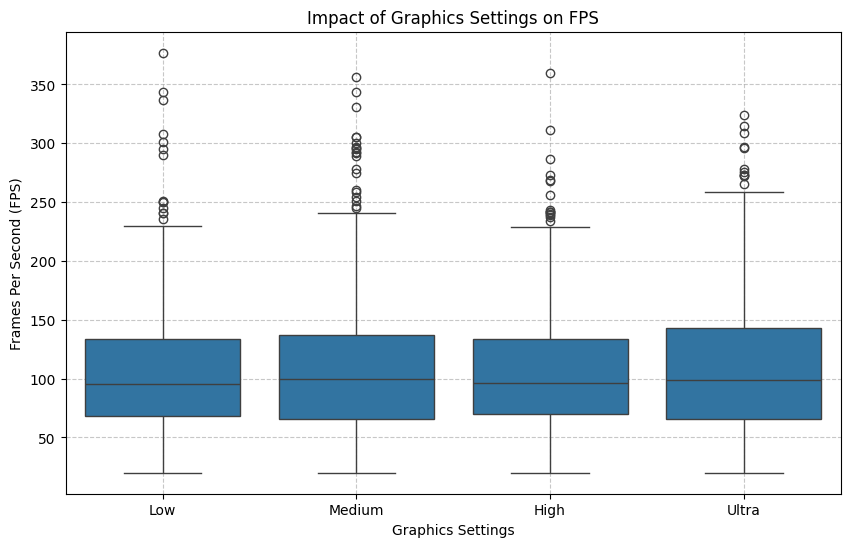

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Graphics_Settings', y='FPS', data=df, order=['Low', 'Medium', 'High', 'Ultra'])
plt.title('Impact of Graphics Settings on FPS')
plt.xlabel('Graphics Settings')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'Linear_Regression_Cleaned': LinearRegression(),
    'Random_Forest_Cleaned': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient_Boosting_Cleaned': GradientBoostingRegressor(random_state=42),
    'XGBoost_Cleaned': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM_Cleaned': LGBMRegressor(random_state=42, n_jobs=-1)
}

results_cleaned = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline_cleaned = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('regressor', model)])

    pipeline_cleaned.fit(X_train_cleaned, y_train_cleaned)

    y_pred_cleaned = pipeline_cleaned.predict(X_test_cleaned)

    mae_cleaned = mean_absolute_error(y_test_cleaned, y_pred_cleaned)
    mse_cleaned = mean_squared_error(y_test_cleaned, y_pred_cleaned)
    rmse_cleaned = np.sqrt(mse_cleaned)
    r2_cleaned = r2_score(y_test_cleaned, y_pred_cleaned)

    results_cleaned.append({
        'Model': name,
        'MAE': mae_cleaned,
        'MSE': mse_cleaned,
        'RMSE': rmse_cleaned,
        'R2 Score': r2_cleaned
    })
    print(f"{name} - MAE: {mae_cleaned:.2f}, MSE: {mse_cleaned:.2f}, RMSE: {rmse_cleaned:.2f}, R2 Score: {r2_cleaned:.2f}")

comparison_df = pd.DataFrame(results_cleaned)

print("\nModel retraining and evaluation on cleaned data complete.")


Training Linear_Regression_Cleaned...
Linear_Regression_Cleaned - MAE: 32.48, MSE: 1693.81, RMSE: 41.16, R2 Score: 0.22

Training Random_Forest_Cleaned...
Random_Forest_Cleaned - MAE: 27.87, MSE: 1256.58, RMSE: 35.45, R2 Score: 0.42

Training Gradient_Boosting_Cleaned...
Gradient_Boosting_Cleaned - MAE: 27.94, MSE: 1259.07, RMSE: 35.48, R2 Score: 0.42

Training XGBoost_Cleaned...
XGBoost_Cleaned - MAE: 29.71, MSE: 1464.36, RMSE: 38.27, R2 Score: 0.32

Training LightGBM_Cleaned...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 1550, number of used features: 98
[LightGBM] [Info] Start training from score 103.810968
LightGBM_Cleaned - MAE: 28.35, MSE: 1320.58, RMSE: 36.34, R2 Score: 0.39

Model retraining and evaluation on cleaned data complete.


**TEST CASE**

In [ ]:
# Define a sample input scenario for prediction
sample_input_dict = {
    'CPU_Name': 'Core i9-13900K',
    'CPU_Score': 35000,
    'CPU_Type': 'Desktop',
    'GPU_Name': 'RTX 4090',
    'GPU_Score': 45000,
    'GPU_Type': 'Desktop',
    'RAM_Size': 32,
    'Game_Name': 'Cyberpunk 2077',
    'Resolution': '2560x1440',
    'Refresh_Rate': 144,
    'Graphics_Settings': 'Ultra',
    'Shadow_Quality': 'High',
    'Anti_Aliasing_Mode': 'TAA',
    'DLSS_FSR': 'Quality',
    'Ray_Tracing': 'High',
    'NVIDIA_Power_Management_Mode': 'Prefer maximum performance',
    'NVIDIA_Low_Latency_Mode': 'Ultra',
    'NVIDIA_Texture_Filtering_Quality': 'High Quality',
    'OS_Game_Mode': 'On',
    'OS_Hardware_Accelerated_GPU_Scheduling': 'On',
    'OS_Power_Plan': 'High Performance',
    'Preferred_Graphics_Processor': 'High-performance NVIDIA processor',
    'Max_Frame_Rate': 'Off',
    'V_Sync': 'Off',
    'Triple_Buffering': 'Off',
    'Shader_Cache_Size': 'Unlimited',
    'Anisotropic_Sample_Optimization': 'On',
    'Threaded_Optimization': 'Auto',
    'Image_Scaling_NIS': 'Off',
    'In_Game_Overlay': 'Disabled',
    'Whisper_Mode': 'Off',
    'Battery_Boost': 'Off'
}

# Create a DataFrame from the sample input, ensuring correct column order
# X.columns represents the feature columns the model was trained on.
predict_df = pd.DataFrame([sample_input_dict]).reindex(columns=X.columns, fill_value=None)

# prediction using the tuned model
predicted_fps_single = Random_Forest_Optimizer.predict(predict_df)[0]

print(f"Predicted FPS for the given input scenario: {predicted_fps_single:.2f}")

Predicted FPS for the given input scenario: 197.71


### Hyperparameter Tuning for Random Forest Regressor

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

# Create a new pipeline for Grid Search
# We'll use a fresh Random Forest Regressor instance to avoid any previous state
rf_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])

# Initialize GridSearchCV
grid_search = GridSearchCV(rf_pipeline_for_tuning, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)

print("Starting Grid Search for Random Forest Regressor...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nGrid Search complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters found: {best_params}")
print(f"Best R2 Score (cross-validated): {best_score:.4f}")

# Update best_model_pipeline with the best estimator found by GridSearchCV
Random_Forest_Optimizer = grid_search.best_estimator_

print("Updated the best model pipeline with tuned hyperparameters.")

Starting Grid Search for Random Forest Regressor...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Grid Search complete.
Best Parameters found: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150}
Best R2 Score (cross-validated): 0.4892
Updated the best model pipeline with tuned hyperparameters.


### Evaluating the Tuned Random Forest Regressor



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions with the tuned model
y_pred_tuned = Random_Forest_Optimizer.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest Regressor - MAE: {mae_tuned:.2f}, MSE: {mse_tuned:.2f}, RMSE: {rmse_tuned:.2f}, R2 Score: {r2_tuned:.2f}")

# Add tuned model results to the comparison DataFrame
tuned_rf_results = {
    'Model': 'Random Forest Regressor (Tuned)',
    'MAE': mae_tuned,
    'MSE': mse_tuned,
    'RMSE': rmse_tuned,
    'R2 Score': r2_tuned
}

# Combine all results into a single DataFrame
# 'results' contains models on original data (from 1395f59b)
# 'results_cleaned' contains models on cleaned data (from ec3372ce)
# 'tuned_rf_results' is the tuned model

all_results_df = pd.concat([
    pd.DataFrame(results),
    pd.DataFrame(results_cleaned),
    pd.DataFrame([tuned_rf_results])
], ignore_index=True)

# Assign to full_comparison_df to be used by subsequent cells
full_comparison_df = all_results_df.copy()

display(full_comparison_df.sort_values(by='R2 Score', ascending=False))

Tuned Random Forest Regressor - MAE: 31.49, MSE: 1663.43, RMSE: 40.79, R2 Score: 0.51


,Model,MAE,MSE,RMSE,R2 Score
8,Random Forest Regressor (Tuned),31.493135,1663.430514,40.785175,0.514306
1,Random_Forest,31.745750,1676.118642,40.940428,0.510602
2,Gradient_Boosting,32.098278,1718.946226,41.460176,0.498097
4,Random_Forest_Cleaned,27.866418,1256.575914,35.448215,0.419191
5,Gradient_Boosting_Cleaned,27.944705,1259.067228,35.483337,0.418039
7,LightGBM_Cleaned,28.345937,1320.576056,36.339731,0.389609
6,XGBoost_Cleaned,29.713043,1464.359497,38.266950,0.323150
0,Linear_Regression,39.411485,2463.425573,49.632908,0.280721
3,Linear_Regression_Cleaned,32.481345,1693.814308,41.155975,0.217092


### R2 Score comparison of all models

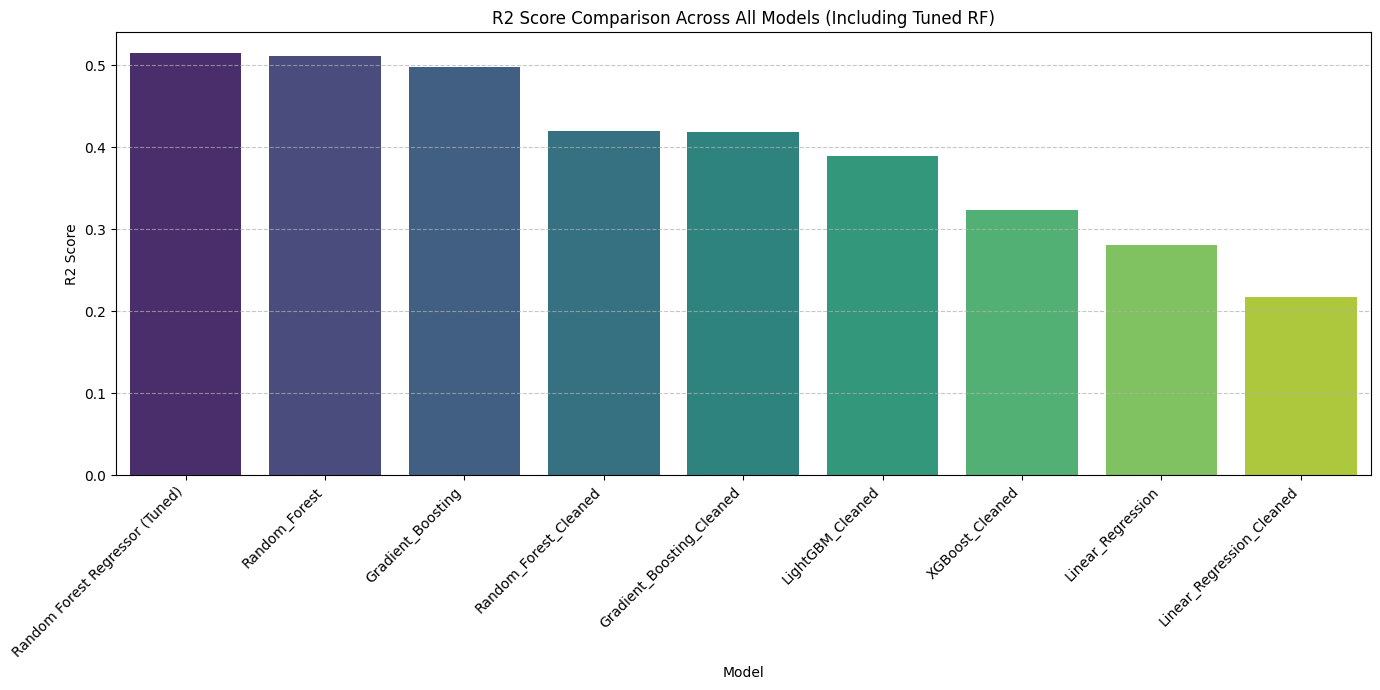

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='R2 Score', data=full_comparison_df.sort_values(by='R2 Score', ascending=False), palette='viridis')
plt.title('R2 Score Comparison Across All Models (Including Tuned RF)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Test 3

In [ ]:
new_sample_input_dict = {
    'CPU_Name': 'Ryzen 7 5800X',
    'CPU_Score': 25000,
    'CPU_Type': 'Desktop',
    'GPU_Name': 'RTX 3070',
    'GPU_Score': 22000,
    'GPU_Type': 'Desktop',
    'RAM_Size': 16,
    'Game_Name': 'Elden Ring',
    'Resolution': '2560x1440',
    'Refresh_Rate': 144,
    'Graphics_Settings': 'High',
    'Shadow_Quality': 'Medium',
    'Anti_Aliasing_Mode': 'TAA',
    'DLSS_FSR': 'Balanced',
    'Ray_Tracing': 'Off',
    'NVIDIA_Power_Management_Mode': 'Prefer maximum performance',
    'NVIDIA_Low_Latency_Mode': 'On',
    'NVIDIA_Texture_Filtering_Quality': 'Quality',
    'OS_Game_Mode': 'On',
    'OS_Hardware_Accelerated_GPU_Scheduling': 'Off',
    'OS_Power_Plan': 'Balanced',
    'Preferred_Graphics_Processor': 'High-performance NVIDIA processor',
    'Max_Frame_Rate': '144',
    'V_Sync': 'Off',
    'Triple_Buffering': 'Off',
    'Shader_Cache_Size': 'Unlimited',
    'Anisotropic_Sample_Optimization': 'On',
    'Threaded_Optimization': 'Auto',
    'Image_Scaling_NIS': 'Off',
    'In_Game_Overlay': 'Disabled',
    'Whisper_Mode': 'Off',
    'Battery_Boost': 'Off'
}

# Create a DataFrame from the new sample input, ensuring correct column order
# X.columns represents the feature columns the model was trained on.
new_predict_df = pd.DataFrame([new_sample_input_dict]).reindex(columns=X.columns, fill_value=None)

# Make the prediction using the tuned model
predicted_fps_new_scenario = Random_Forest_Optimizer.predict(new_predict_df)[0]

print(f"Predicted FPS for the new scenario with tuned model: {predicted_fps_new_scenario:.2f}")

Predicted FPS for the new scenario with tuned model: 107.31


In [ ]:
print(f"--- Optimal Settings Search for {new_sample_input_dict['CPU_Name']} and {new_sample_input_dict['GPU_Name']} ---")
print(f"Game: {new_sample_input_dict['Game_Name']}")

demo_desired_resolution = '2560x1440'
demo_desired_refresh_rate = 144
demo_desired_fps_for_search = 90

recommended_settings_for_new_setup, achieved_fps_for_new_setup = find_optimal_settings(
    cpu_name=new_sample_input_dict['CPU_Name'],
    cpu_score=new_sample_input_dict['CPU_Score'],
    cpu_type=new_sample_input_dict['CPU_Type'],
    gpu_name=new_sample_input_dict['GPU_Name'],
    gpu_score=new_sample_input_dict['GPU_Score'],
    gpu_type=new_sample_input_dict['GPU_Type'],
    ram_size=new_sample_input_dict['RAM_Size'],
    game_name=new_sample_input_dict['Game_Name'],
    desired_resolution=demo_desired_resolution,
    desired_refresh_rate=demo_desired_refresh_rate,
    desired_fps=demo_desired_fps_for_search,
    model_pipeline=Random_Forest_Optimizer,
    X_cols=X.columns
)

if recommended_settings_for_new_setup:
    print(f"\n--- Recommended Settings (Achieved FPS: {achieved_fps_for_new_setup:.2f}) ---")
    for setting, value in recommended_settings_for_new_setup.items():
        print(f"{setting}: {value}")
else:
    print("\nCould not find suitable settings for the given parameters and desired FPS.")

--- Optimal Settings Search for Ryzen 7 5800X and RTX 3070 ---
Game: Elden Ring

--- Recommended Settings (Achieved FPS: 104.59) ---
Resolution: 2560x1440
Refresh_Rate: 144
Graphics_Settings: Low
DLSS_FSR: Performance
Ray_Tracing: Off
Max_Frame_Rate: Off
V_Sync: Off
OS_Power_Plan: High Performance
Shadow_Quality: Medium
Anti_Aliasing_Mode: TAA
NVIDIA_Power_Management_Mode: Prefer maximum performance
NVIDIA_Low_Latency_Mode: Ultra
NVIDIA_Texture_Filtering_Quality: High performance
OS_Game_Mode: On
OS_Hardware_Accelerated_GPU_Scheduling: On
Preferred_Graphics_Processor: High-performance NVIDIA processor
Triple_Buffering: Off
Shader_Cache_Size: Unlimited
Anisotropic_Sample_Optimization: On
Threaded_Optimization: Auto
Image_Scaling_NIS: Off
In_Game_Overlay: Disabled
Whisper_Mode: Off
Battery_Boost: Off


In [ ]:
pip install sheryanalysis==0.1.0

In [ ]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (2000, 33)


...


🔢 Numerical Columns: ['FPS']


INFO:sheryanalysis:
🔢 Numerical Columns: ['FPS']



📝 Text Columns: ['CPU_Name', 'Game_Name']


INFO:sheryanalysis:
📝 Text Columns: ['CPU_Name', 'Game_Name']


{'shape': (2000, 33),
 'columns': ['CPU_Name',
  'CPU_Score',
  'CPU_Type',
  'GPU_Name',
  'GPU_Score',
  'GPU_Type',
  'RAM_Size',
  'Game_Name',
  'Resolution',
  'Refresh_Rate',
  'Graphics_Settings',
  'Shadow_Quality',
  'Anti_Aliasing_Mode',
  'DLSS_FSR',
  'Ray_Tracing',
  'NVIDIA_Power_Management_Mode',
  'NVIDIA_Low_Latency_Mode',
  'NVIDIA_Texture_Filtering_Quality',
  'OS_Game_Mode',
  'OS_Hardware_Accelerated_GPU_Scheduling',
  'OS_Power_Plan',
  'Preferred_Graphics_Processor',
  'Max_Frame_Rate',
  'V_Sync',
  'Triple_Buffering',
  'Shader_Cache_Size',
  'Anisotropic_Sample_Optimization',
  'Threaded_Optimization',
  'Image_Scaling_NIS',
  'In_Game_Overlay',
  'Whisper_Mode',
  'Battery_Boost',
  'FPS'],
 'dtypes': {'CPU_Name': dtype('O'),
  'CPU_Score': dtype('int64'),
  'CPU_Type': dtype('O'),
  'GPU_Name': dtype('O'),
  'GPU_Score': dtype('int64'),
  'GPU_Type': dtype('O'),
  'RAM_Size': dtype('int64'),
  'Game_Name': dtype('O'),
  'Resolution': dtype('O'),
  'Refresh_

In [ ]:
import joblib
joblib.dump(model, 'Random_Forest_Optimizer.joblib')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')


['columns.pkl']